In [1]:
import numpy as np
import scipy as sp 
from matplotlib import pyplot as plt

import morph_analyses as m

%load_ext autoreload
%autoreload 2

%matplotlib inline

## Example lick rasters

In [8]:
mouse = 'FD1'
metadata = m.mouse_metadata.frequent_w_decision_sessions[mouse]
sess_deets = metadata['test_sessions'][4]
sess = m.sess.CA1MorphSession.from_nwb(mouse,'testing',sess_deets['day'])

In [9]:
sess.trial_info.keys()

dict_keys(['morphs', 'max_pos', 'rewards', 'zone0_licks', 'zone1_licks', 'zone0_speed', 'zone1_speed', 'pcnt', 'wallJitter', 'towerJitter', 'bckgndJitter', 'pos_lick', 'omissions', 'reward_pos', 'rzone_entry', 'effective_morph'])

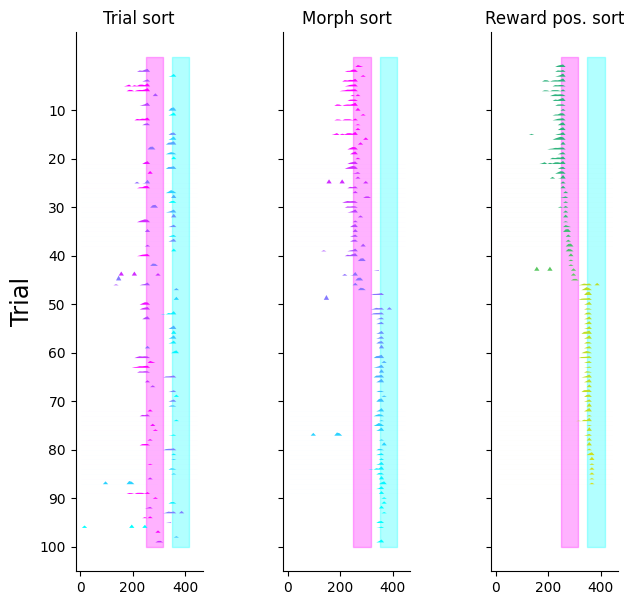

In [10]:
lick_trial_mat = sess.trial_matrices['licks']
centers = sess.trial_matrices['bin_centers']
eff_morph = sess.trial_info['effective_morph']
reward_pos = sess.trial_info['reward_pos']
f_lick, axarr_lick = m.behavior.behavior_raster_task(lick_trial_mat/np.nanmax(lick_trial_mat.ravel()),
                                                        centers,eff_morph,reward_pos/390.,smooth=False)

## Average morph binned lick rate

In [18]:
lick_list = []
for mouse, metadata in m.mouse_metadata.frequent_w_decision_sessions.items():
    
    sess_list = metadata['test_sessions']
    if len(sess_list)==0:
        continue
    
    mouse_lick_mat = 0
    for s, sess_deets in enumerate(sess_list):
        
        sess = m.sess.CA1MorphSession.from_nwb(mouse, 'testing', sess_deets['day'])
        bin_centers = sess.trial_matrices['bin_centers']
        morphs = sess.trial_info['morphs']
        lick_mat = sess.trial_matrices['licks']
        lick_mat[np.isnan(lick_mat)]=0
        lick_mat /= lick_mat.ravel().mean()
        
        lick_morph_mat = np.zeros([1,5,45])
        for i, _m in enumerate([0, .25, .5, .75, 1]):
            
            morph_mask = morphs==_m
            lick_morph_mat[:,i,:] = np.nanmean(lick_mat[morphs==_m, :],axis=0)
    
        mouse_lick_mat += lick_morph_mat
    mouse_lick_mat /= s+1
    
    lick_list.append(mouse_lick_mat)
    
        

In [19]:
lick_mat = np.concatenate(lick_list, axis=0)
print(lick_mat.shape)

(3, 5, 45)


Text(0.5, 1.0, 'Average From Frequent Morph Trained (no timeouts)')

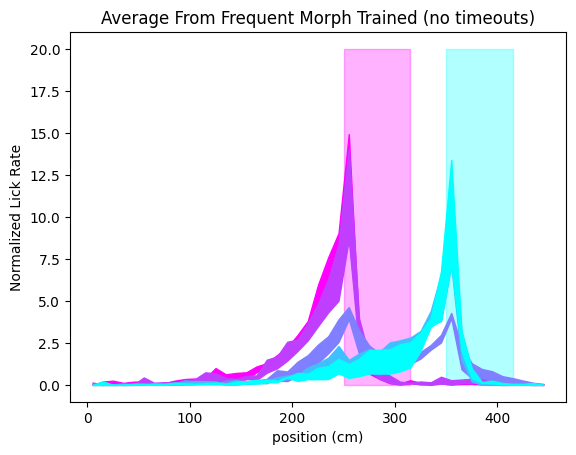

In [22]:
fig, ax = plt.subplots()
for i, _m in enumerate([0, .25, .5, .75, 1]):
    mu, sem = lick_mat[:,i,:].mean(axis=0), sp.stats.sem(lick_mat[:,i,:], axis=0)
    ax.fill_between(bin_centers, mu+sem, mu-sem, color=plt.cm.cool(1-float(_m)))
                    
ax.fill_betweenx([0,20],250,315,color=plt.cm.cool(1.),alpha=.3,zorder=0)
ax.fill_betweenx([0,20],350,415,color=plt.cm.cool(0.),alpha=.3,zorder=0)
ax.set_ylabel('Normalized Lick Rate')
ax.set_xlabel('position (cm)')
ax.set_title('Average From Frequent Morph Trained (no timeouts)')